<a href="https://colab.research.google.com/github/tbattal1/Cargo-Specific-Risk-Profiling/blob/main/ART_45_Asama1b_Colab_ipynb_adl%C4%B1_not_defterinin_kopyas%C4%B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ART_45_Bluecarbon — Aşama 1b (Colab): Ortak grid'e harmonizasyon
Tüm katmanları ortak bir grid'e getirir ve MCDM'e hazır bir tablo üretir:
**Posidonia fraksiyonu**, **MPA varlığı**, **limana uzaklık**, **vessel density değerleri** (cargo/tanker/passenger/pleasure/sailing/all) ve **demirleme göstergesi**.

Colab'da sırayla çalıştırın. WCS (raster değerleri) kısmı en hassas adım; hata verirse çıktıyı paylaşın, eksen adını düzeltiriz. Çıktı: `art45_grid.csv` + özet haritalar.


In [ ]:
# 1) Kurulum
!pip -q install owslib geopandas rasterio rioxarray xarray requests matplotlib shapely pyproj scipy 2>/dev/null
print("kurulum tamam")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.3/241.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.1 MB/s eta 0:00:00
kurulum tamam


In [ ]:
# 2) Ayarlar + kilitli katman adları (Aşama 1a'dan)
import io, requests, numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box, Point
import warnings; warnings.filterwarnings("ignore")

BBOX=(-6.0,35.0,16.5,45.0)          # lon_min,lat_min,lon_max,lat_max (WGS84)
RES=0.05                             # ~5.5 km grid (ilk geçiş; sonra 1 km'ye inebiliriz)

SEA_WFS="https://ows.emodnet-seabedhabitats.eu/geoserver/emodnet_open/wfs"
HUM_WFS="https://ows.emodnet-humanactivities.eu/wfs"
HUM_WCS="https://ows.emodnet-humanactivities.eu/wcs"

POSIDONIA="emodnet_open:art17_hab_1120"
MPA="emodnet:marineprotectedareas"
PORTS="emodnet:portlocations"
VD={"cargo":"emodnet:vesseldensity_09avg","tanker":"emodnet:vesseldensity_10avg",
    "passenger":"emodnet:vesseldensity_08avg","pleasure":"emodnet:vesseldensity_05avg",
    "sailing":"emodnet:vesseldensity_04avg","all":"emodnet:vesseldensity_allavg"}
print("ayarlar hazır | RES:", RES)

ayarlar hazır | RES: 0.05


In [ ]:
# 3) WFS yardımcı + grid oluştur
def wfs(url, typ, count=100000):
    p={"service":"WFS","version":"2.0.0","request":"GetFeature","typeNames":typ,
       "outputFormat":"application/json","count":str(count),"srsName":"EPSG:4326",
       "bbox":f"{BBOX[1]},{BBOX[0]},{BBOX[3]},{BBOX[2]},urn:ogc:def:crs:EPSG::4326"}
    r=requests.get(url,params=p,timeout=300); return gpd.read_file(io.BytesIO(r.content))

# grid hücre merkezleri + poligonları
lons=np.arange(BBOX[0]+RES/2, BBOX[2], RES)
lats=np.arange(BBOX[1]+RES/2, BBOX[3], RES)
XX,YY=np.meshgrid(lons,lats)
cx=XX.ravel(); cy=YY.ravel()
cells=[box(x-RES/2,y-RES/2,x+RES/2,y+RES/2) for x,y in zip(cx,cy)]
grid=gpd.GeoDataFrame({"cx":cx,"cy":cy}, geometry=cells, crs="EPSG:4326").reset_index(drop=True)
grid["cid"]=grid.index
print("grid hücre sayısı:", len(grid))

grid hücre sayısı: 90000


In [ ]:
# 4) Posidonia fraksiyonu (poligon kesişim alanı / hücre alanı)
pos=wfs(SEA_WFS, POSIDONIA)
print("posidonia feature:", len(pos))
pos_m=pos.to_crs(3035); grid_m=grid.to_crs(3035)
grid_m["cell_area"]=grid_m.area
inter=gpd.overlay(grid_m[["cid","cell_area","geometry"]], pos_m[["geometry"]], how="intersection")
inter["a"]=inter.area
frac=inter.groupby("cid")["a"].sum()
grid["posidonia_frac"]=(grid["cid"].map(frac).fillna(0) / grid_m["cell_area"]).clip(0,1)
print("Posidonia içeren hücre:", int((grid.posidonia_frac>0).sum()))

posidonia feature: 12
Posidonia içeren hücre: 4390


In [ ]:
# 5) MPA varlığı + 6) Limana uzaklık
from scipy.spatial import cKDTree
# MPA
mpa=wfs(HUM_WFS, MPA); print("MPA feature:", len(mpa))
mpa_u=mpa.to_crs(3035).geometry.union_all() if hasattr(mpa.to_crs(3035).geometry,"union_all") else mpa.to_crs(3035).unary_union
cent_m=grid.to_crs(3035).geometry.centroid
grid["in_mpa"]=cent_m.within(mpa_u).astype(int)
print("MPA içi hücre:", int(grid.in_mpa.sum()))
# Limana uzaklık (km)
ports=wfs(HUM_WFS, PORTS); print("port feature:", len(ports))
pm=ports.to_crs(3035)
ptree=cKDTree(np.c_[pm.geometry.x, pm.geometry.y])
d,_=ptree.query(np.c_[cent_m.x, cent_m.y], k=1)
grid["port_dist_km"]=d/1000.0
print("liman uzaklık km — min/median/max:", round(grid.port_dist_km.min(),1), round(grid.port_dist_km.median(),1), round(grid.port_dist_km.max(),1))

MPA feature: 38
MPA içi hücre: 6220
port feature: 131
liman uzaklık km — min/median/max: 0.2 94.2 542.3


In [ ]:
# 7) WCS + time dilimi (zamanı DescribeCoverage'dan al)
import rioxarray, xarray as xr, re
from pyproj import Transformer
tr=Transformer.from_crs(4326,3857,always_xy=True)
x0,y0=tr.transform(BBOX[0],BBOX[1]); x1,y1=tr.transform(BBOX[2],BBOX[3])
def time_val(covid):
    r=requests.get(HUM_WCS, params=[("service","WCS"),("version","2.0.1"),
        ("request","DescribeCoverage"),("coverageId",covid)],timeout=120)
    m=re.findall(r'(\d{4}-\d{2}-\d{2}T[\d:.]+Z)', r.text); return m[-1] if m else None
def wcs_da(cov):
    covid=cov.replace(":","__"); t=time_val(covid)
    p=[("service","WCS"),("version","2.0.1"),("request","GetCoverage"),
       ("coverageId",covid),("format","image/tiff"),
       ("subset",f"X({min(x0,x1)},{max(x0,x1)})"),("subset",f"Y({min(y0,y1)},{max(y0,y1)})")]
    if t: p.append(("subset",f'time("{t}")'))
    r=requests.get(HUM_WCS, params=p, timeout=300)
    if r.headers.get("Content-Type","").lower().startswith(("image","application/octet")):
        return rioxarray.open_rasterio(io.BytesIO(r.content)).squeeze().rio.reproject("EPSG:4326")
    m=re.search(r"ExceptionText>(.*?)</", r.text, re.S)
    raise RuntimeError((m.group(1).strip()[:200] if m else r.text[:200]))
xs=xr.DataArray(grid["cx"].values,dims="pts"); ys=xr.DataArray(grid["cy"].values,dims="pts")
for name,cov in VD.items():
    try:
        da=wcs_da(cov)
        if "time" in getattr(da,"dims",()): da=da.isel(time=0)
        vals=da.sel(x=xs,y=ys,method="nearest").values.astype(float)
        vals=np.where(vals<0,np.nan,vals); grid[f"vd_{name}"]=np.nan_to_num(vals,nan=0.0)
        print(f"[OK] vd_{name}: max={np.nanmax(vals):.1f}")
    except Exception as e:
        grid[f"vd_{name}"]=np.nan; print(f"[HATA] vd_{name}: {e}")

[OK] vd_cargo: max=1023.6
[OK] vd_tanker: max=1472.8
[OK] vd_passenger: max=1510.6
[OK] vd_pleasure: max=25472.9
[OK] vd_sailing: max=10769.1
[OK] vd_all: max=29127.9


In [ ]:
# 8) Demirleme göstergesi + normalizasyon
def norm(s):
    s=pd.to_numeric(grid[s], errors="coerce");
    return (s - s.min())/(s.max()-s.min()) if s.max()>s.min() else s*0
# demirleme baskısı ~ (pleasure + sailing) yoğunluğu, liman yaklaşımıyla ağırlıklı
if "vd_pleasure" in grid and grid["vd_pleasure"].notna().any():
    anc = grid["vd_pleasure"].fillna(0) + grid["vd_sailing"].fillna(0)
    prox = 1/(1+grid["port_dist_km"]/20.0)      # limana yakınlıkta artan ağırlık
    grid["anchoring_proxy"]= (anc*prox)
    grid["anchoring_n"]=norm("anchoring_proxy")
else:
    grid["anchoring_proxy"]=np.nan; grid["anchoring_n"]=np.nan
# transit trafiği (kargo+tanker+yolcu)
grid["transit"]=grid.get("vd_cargo",0).fillna(0)+grid.get("vd_tanker",0).fillna(0)+grid.get("vd_passenger",0).fillna(0)
grid["transit_n"]=norm("transit")
grid["posidonia_n"]=norm("posidonia_frac")
print("normalizasyon tamam. kolonlar:", [c for c in grid.columns if c.endswith('_n') or c.startswith('vd_')])

normalizasyon tamam. kolonlar: ['vd_cargo', 'vd_tanker', 'vd_passenger', 'vd_pleasure', 'vd_sailing', 'vd_all', 'anchoring_n', 'transit_n', 'posidonia_n']


kaydedildi: art45_grid.csv | satır: 90000


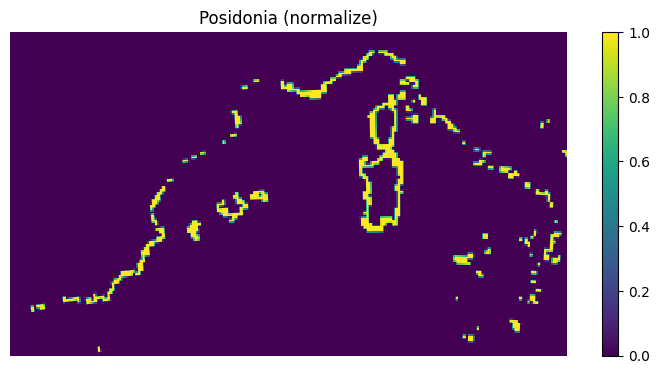

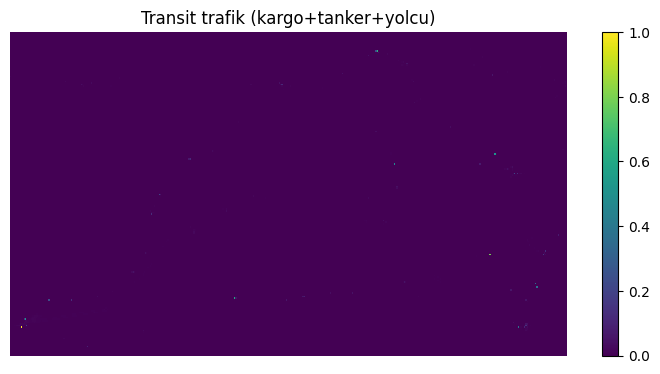

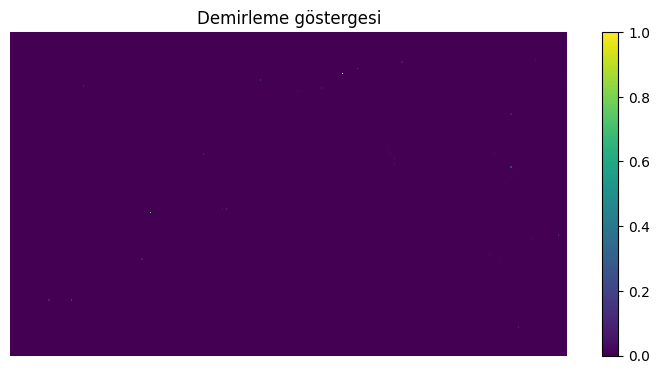

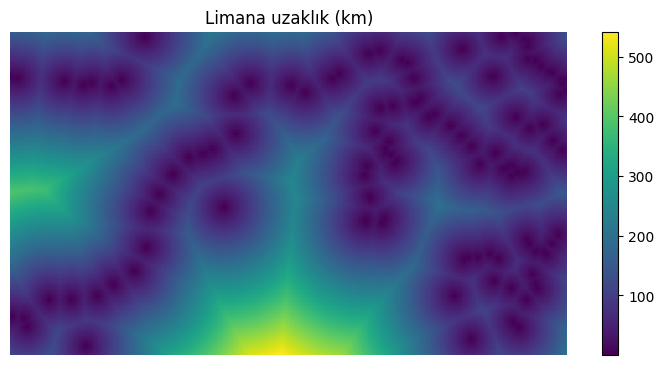


Aşama 1b iskeleti tamam. CSV + haritaları Hocam paylaşırsa Aşama 2'ye (kriter standartlaştırma + ağırlık) geçeriz.


In [ ]:
# 9) Kaydet + özet haritalar
keep=[c for c in grid.columns if c not in ('geometry',)]
grid[keep].to_csv("art45_grid.csv", index=False)
print("kaydedildi: art45_grid.csv | satır:", len(grid))

def plot(col,title):
    fig,ax=plt.subplots(figsize=(9,4.2))
    grid.plot(column=col, ax=ax, markersize=2, legend=True, cmap="viridis")
    ax.set_xlim(BBOX[0],BBOX[2]); ax.set_ylim(BBOX[1],BBOX[3]); ax.set_title(title); ax.axis("off"); plt.show()
plot("posidonia_n","Posidonia (normalize)")
plot("transit_n","Transit trafik (kargo+tanker+yolcu)")
if grid["anchoring_n"].notna().any(): plot("anchoring_n","Demirleme göstergesi")
plot("port_dist_km","Limana uzaklık (km)")
print("\nAşama 1b iskeleti tamam. CSV + haritaları Hocam paylaşırsa Aşama 2'ye (kriter standartlaştırma + ağırlık) geçeriz.")

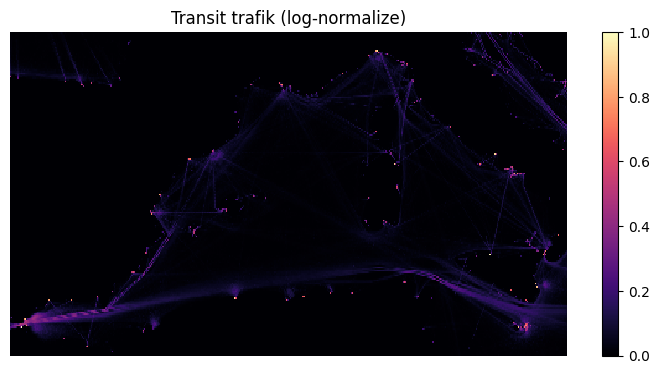

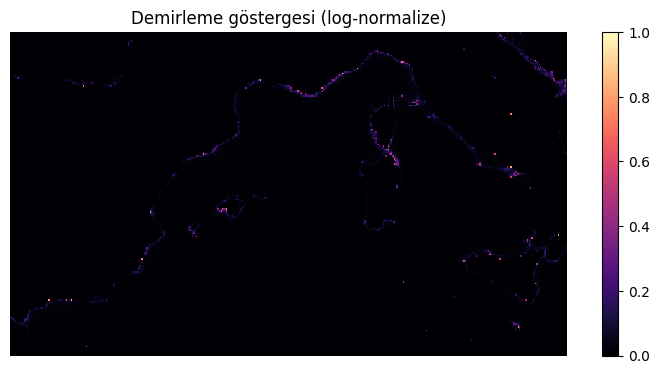

In [ ]:
# 8b) Çarpık baskı kriterlerini LOG ile normalize et
def lognorm(series):
    v=np.log1p(pd.to_numeric(series, errors="coerce").clip(lower=0))
    return (v-v.min())/(v.max()-v.min()) if v.max()>v.min() else v*0
grid["transit_n"]=lognorm(grid["transit"])
grid["anchoring_n"]=lognorm(grid["anchoring_proxy"])
grid.to_csv("art45_grid.csv", index=False)
def plot(col,title):
    fig,ax=plt.subplots(figsize=(9,4.2))
    grid.plot(column=col, ax=ax, markersize=2, legend=True, cmap="magma")
    ax.set_xlim(BBOX[0],BBOX[2]); ax.set_ylim(BBOX[1],BBOX[3]); ax.set_title(title); ax.axis("off"); plt.show()
plot("transit_n","Transit trafik (log-normalize)")
plot("anchoring_n","Demirleme göstergesi (log-normalize)")

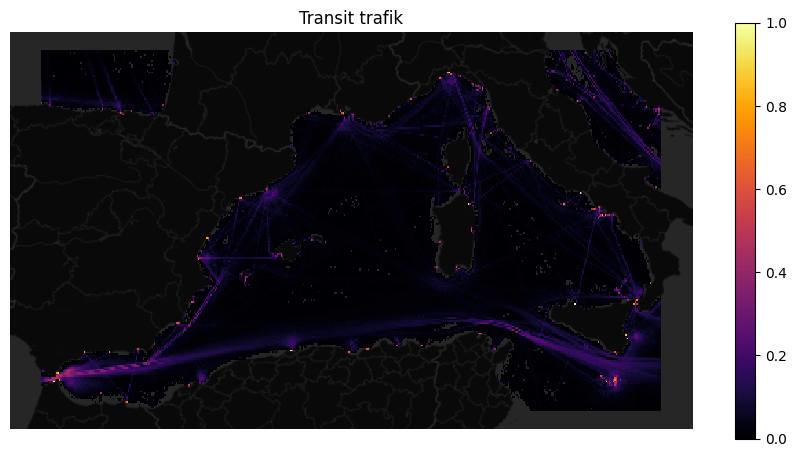

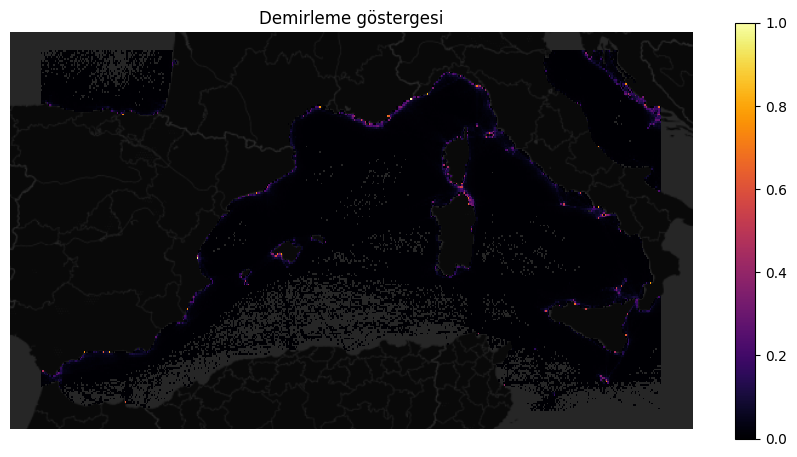

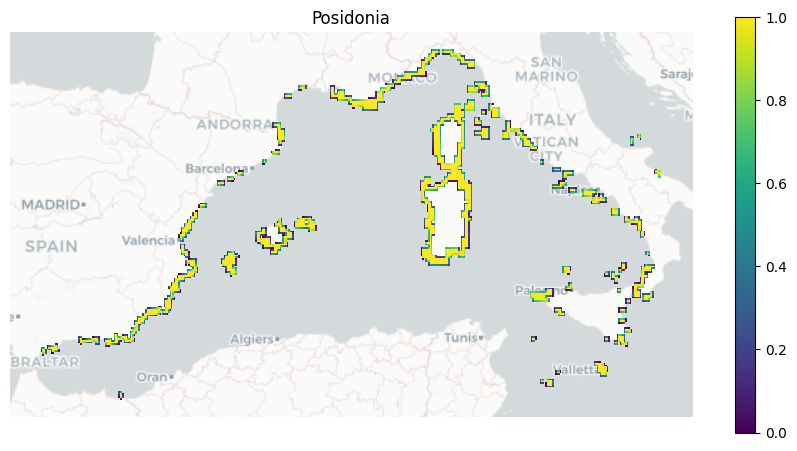

In [ ]:
# 9b) Daha net: kara/kıyı altlığı + colormap seçimi + kontrast
!pip -q install contextily 2>/dev/null
import contextily as cx
CMAP="inferno"   # dene: "inferno", "cividis", "magma", "plasma"
def plot2(col,title,cmap=CMAP,light=False):
    g=grid[grid[col]>0].to_crs(3857)          # sıfır hücreleri gizle -> daha temiz
    fig,ax=plt.subplots(figsize=(11,5.4))
    g.plot(column=col, ax=ax, markersize=4, cmap=cmap, vmin=0, vmax=1, legend=True)
    src = cx.providers.CartoDB.Positron if light else cx.providers.CartoDB.DarkMatterNoLabels
    try: cx.add_basemap(ax, source=src, attribution=False)
    except Exception as e: print("altlık yok:", e)
    ax.set_title(title); ax.axis("off"); plt.show()
plot2("transit_n","Transit trafik")
plot2("anchoring_n","Demirleme göstergesi")
plot2("posidonia_n","Posidonia", cmap="viridis", light=True)